# Avance de proyecto - Ciencia de datos

## Parte 1

Carga la base de datos a Python e importa las librerías que utilizarás a lo largo de todo el análisis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para visualizaciones
sns.set_theme(style="darkgrid")

try:
    df = pd.read_csv('../DataSets/train.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")

# Visualización rápida de los datos
df.head()

Dataset cargado exitosamente.


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## Parte 2

### Análisis Descriptivo


In [9]:
print("Dimensiones del dataset:", df.shape)
print("\nInformación general del dataset:")
df.info()

# Estadísticas descriptivas
print("\n--- Estadísticas ---")
display(df.describe())

# Variables categóricas
print("\n--- Variables Categóricas ---")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())



Dimensiones del dataset: (74111, 29)

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 n

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000



--- Variables Categóricas ---

property_type
property_type
Apartment      49003
House          16511
Condominium     2658
Townhouse       1692
Loft            1244
Name: count, dtype: int64

room_type
room_type
Entire home/apt    41310
Private room       30638
Shared room         2163
Name: count, dtype: int64

amenities
amenities
{}                                                                                                                                                                                                                                                                                                                        586
{"translation missing: en.hosting_amenity_49","translation missing: en.hosting_amenity_50"}                                                                                                                                                                                                                               135
{"Family/kid friendly"}       

C:\Users\USER\AppData\Local\Temp\ipykernel_23652\4128543272.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## Graficas Visuales

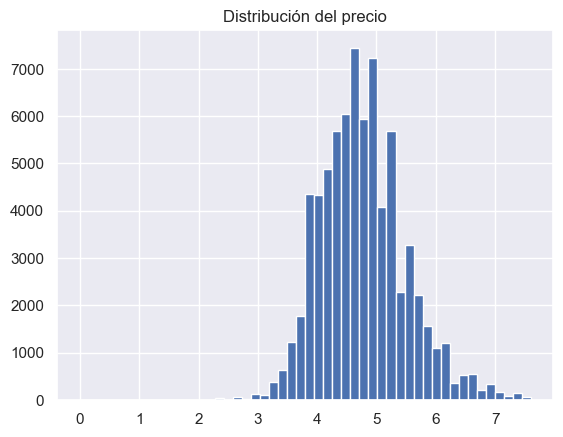

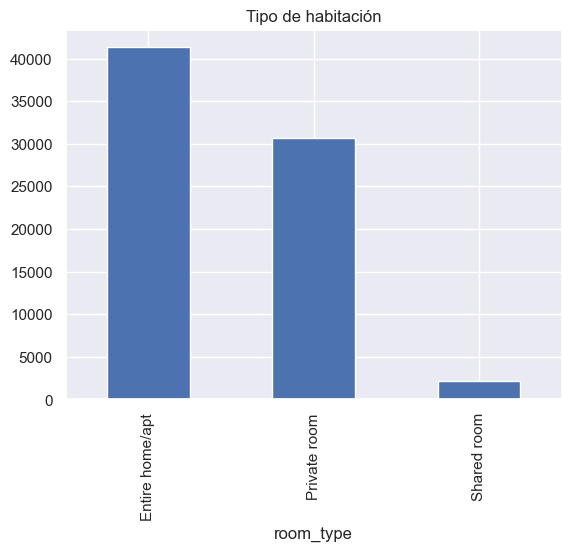

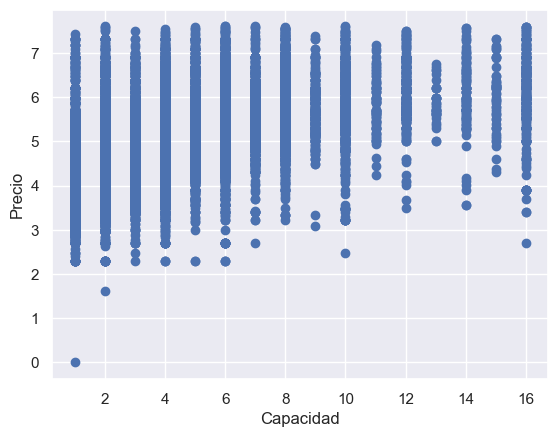

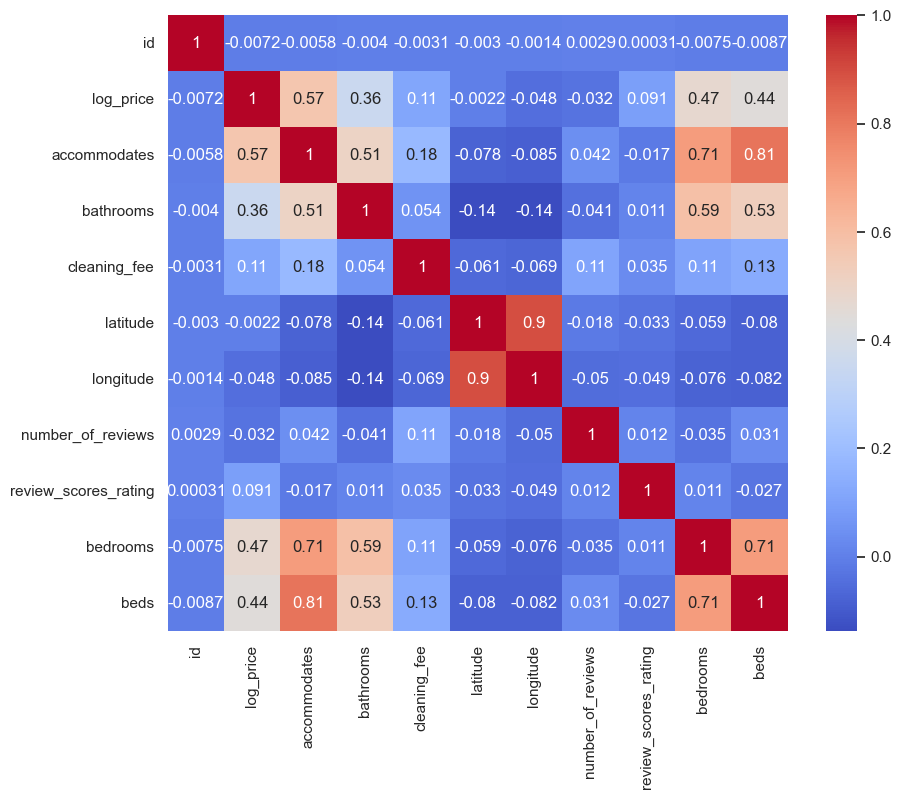

In [10]:
# Histograma del precio
df['log_price'].hist(bins=50)
plt.title("Distribución del precio")
plt.show()

# Grafico de barras tipo de habitación
df['room_type'].value_counts().plot(kind='bar')
plt.title("Tipo de habitación")
plt.show()

#Grafico de dispersión precio/capacidad
plt.scatter(df['accommodates'], df['log_price'])
plt.xlabel("Capacidad")
plt.ylabel("Precio")
plt.show()

# Mapa de calor de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Interpretaciones

- Los precios siempre varian entre los 4 y 6 dolares
- La mayoria de estos registros son de apartamentos o casa completas
- Muy poca gente renta AIRBNB compartido con otra persona
- Aun que no hay gran relacion entre el precio y la capacidad, se ve como entre mas capacidad, menos varia el precio
- Hay gran relacion entre el numero de camas con la capacidad de personas y habitaciones
